# 09 — FL Client Data Partitioning

**Goal:** Partition the CICIoT2023 cat8 training labels into per-client splits that simulate realistic federated deployments.

In real IoT networks, different gateways or subnets see very different traffic patterns — DDoS traffic may dominate one segment while another sees mostly benign traffic. We model this *statistical heterogeneity* (Non-IID) using a **Dirichlet distribution** over class labels.

Three partition schemes are produced:

| Scheme | Description |
|--------|-------------|
| IID | Each client gets a uniform random draw — equal class proportions everywhere |
| Dirichlet α=0.3 | Moderate heterogeneity — clients have uneven class distributions |
| Dirichlet α=0.1 | High heterogeneity — some clients are nearly single-class |

Lower α → more concentrated Dirichlet draws → stronger Non-IID effect.

**Outputs:** index arrays (`.npz`), per-client class count CSVs, and heatmap plots. Only the training labels are partitioned here; features are loaded on-demand by the FL simulation (nb10).

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

NUM_CLIENTS = 10
ALPHAS = [0.3, 0.1]
RANDOM_SEED = 42

# Notebook lives in experiments/stage2_fl/notebooks/
# parents[0] = stage2_fl, parents[1] = experiments, parents[2] = project root
NOTEBOOK_DIR = Path(os.path.abspath("")).resolve()
ROOT = NOTEBOOK_DIR.parents[2]

DATA_DIR   = ROOT / "extracted"
OUTPUT_DIR = ROOT / "experiments" / "stage2_fl" / "partitioning"
PLOTS_DIR  = ROOT / "experiments" / "stage2_fl" / "plots"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("ROOT:        ", ROOT)
print("DATA_DIR:    ", DATA_DIR, "| exists:", DATA_DIR.exists())
print("OUTPUT_DIR:  ", OUTPUT_DIR, "| exists:", OUTPUT_DIR.exists())
print("PLOTS_DIR:   ", PLOTS_DIR, "| exists:", PLOTS_DIR.exists())

assert DATA_DIR.exists(), f"DATA_DIR not found: {DATA_DIR}"

NOTEBOOK_DIR: /Users/satyam/Documents/COS791/CICIoT2023/experiments/stage2_fl/notebooks
ROOT:         /Users/satyam/Documents/COS791/CICIoT2023
DATA_DIR:     /Users/satyam/Documents/COS791/CICIoT2023/extracted | exists: True
OUTPUT_DIR:   /Users/satyam/Documents/COS791/CICIoT2023/experiments/stage2_fl/partitioning | exists: True
PLOTS_DIR:    /Users/satyam/Documents/COS791/CICIoT2023/experiments/stage2_fl/plots | exists: True


## Cell 2 — Load training labels

We only need `y_train_cat8.csv` (integer-encoded class labels) and `cat8_mapping.json` (index → class name) for partitioning. The feature matrix `X_train_cat8.csv` is **not loaded here** — it stays on disk and is indexed by the client index arrays during FL training.

This keeps memory usage low: y_train_cat8 is ~12 MB vs ~2 GB for X_train.

In [2]:
# Load labels
y_train = pd.read_csv(DATA_DIR / "y_train_cat8.csv").squeeze().to_numpy().astype(int)

# Load class name mapping
with open(DATA_DIR / "cat8_mapping.json") as f:
    cat8_mapping = json.load(f)   # {"DDoS": 0, "DoS": 1, ...}

# Build ordered list of class names (index 0 .. num_classes-1)
num_classes  = len(cat8_mapping)
id_to_category = {int(v): k for k, v in cat8_mapping.items()}
class_names  = [id_to_category[i] for i in range(num_classes)]
total_train  = len(y_train)

print(f"Training samples : {total_train:,}")
print(f"Classes ({num_classes})       : {class_names}")
print(f"Label dtype      : {y_train.dtype}")
print()

# Overall class distribution
unique, counts = np.unique(y_train, return_counts=True)
print("Global class distribution:")
for cls, cnt in zip(unique, counts):
    print(f"  {class_names[cls]:12s}  {cnt:>8,}  ({cnt/total_train*100:.2f}%)")

Training samples : 14,703,605
Classes (8)       : ['DDoS', 'DoS', 'Mirai', 'Benign', 'Recon', 'Spoofing', 'Web', 'BruteForce']
Label dtype      : int64

Global class distribution:
  DDoS          8,604,445  (58.52%)
  DoS           2,925,190  (19.89%)
  Mirai         1,651,428  (11.23%)
  Benign         733,115  (4.99%)
  Recon          458,825  (3.12%)
  Spoofing       305,243  (2.08%)
  Web             16,595  (0.11%)
  BruteForce       8,764  (0.06%)


## Cell 3 — IID partition

The IID baseline shuffles all training indices randomly then splits them into `NUM_CLIENTS` equal-sized chunks. Each client receives the same class distribution as the global dataset — this is the best-case scenario for federated learning and serves as an upper bound for expected FL performance.

In [3]:
rng = np.random.default_rng(RANDOM_SEED)

# Shuffle all indices and split evenly
all_indices  = np.arange(total_train)
shuffled     = rng.permutation(all_indices)
iid_splits   = np.array_split(shuffled, NUM_CLIENTS)

# Build per-client class count matrix  (clients × classes)
iid_counts = np.zeros((NUM_CLIENTS, num_classes), dtype=int)
for c, idx in enumerate(iid_splits):
    for cls in range(num_classes):
        iid_counts[c, cls] = np.sum(y_train[idx] == cls)

# Save index arrays
iid_npz_path = OUTPUT_DIR / "iid_client_indices.npz"
np.savez_compressed(iid_npz_path, **{f"client_{c}": iid_splits[c] for c in range(NUM_CLIENTS)})

# Save class count CSV
iid_csv_path = OUTPUT_DIR / "iid_client_class_counts.csv"
df_iid = pd.DataFrame(iid_counts, columns=class_names, index=[f"client_{c}" for c in range(NUM_CLIENTS)])
df_iid.index.name = "client"
df_iid.to_csv(iid_csv_path)

print(f"IID partition saved → {iid_npz_path.name}")
print(f"Class counts CSV  → {iid_csv_path.name}")
print(f"\nSamples per client: {[len(s) for s in iid_splits]}")
print("\nFirst 3 clients (class counts):")
print(df_iid.head(3).to_string())

IID partition saved → iid_client_indices.npz
Class counts CSV  → iid_client_class_counts.csv

Samples per client: [1470361, 1470361, 1470361, 1470361, 1470361, 1470360, 1470360, 1470360, 1470360, 1470360]

First 3 clients (class counts):
            DDoS     DoS   Mirai  Benign  Recon  Spoofing   Web  BruteForce
client                                                                     
client_0  860766  292240  165034   73189  46031     30522  1666         913
client_1  860453  291946  165138   73542  46223     30508  1688         863
client_2  860653  292312  164793   73254  46268     30460  1711         910


## Cell 4 — Dirichlet partition function

The **Dirichlet partitioning** algorithm works class by class:

1. For each class, draw a Dirichlet sample of length `num_clients` — this gives the *proportion* of that class's samples each client receives.
2. Assign samples accordingly.
3. Enforce a `min_samples_per_client` floor to avoid empty splits that would crash FL training.

The result is that clients have heterogeneous class distributions: with α=0.1, one client might have 80% DDoS traffic while another has almost none.

In [4]:
def dirichlet_partition(y, num_clients, alpha, seed, min_samples_per_client=10):
    """
    Partition indices of y into num_clients subsets using Dirichlet(alpha).

    Returns
    -------
    client_indices : list of np.ndarray
        Each element is the array of training indices assigned to that client.
    """
    rng        = np.random.default_rng(seed)
    classes    = np.unique(y)
    client_idx = [[] for _ in range(num_clients)]

    for cls in classes:
        cls_indices = np.where(y == cls)[0]
        rng.shuffle(cls_indices)

        # Dirichlet proportions for this class across clients
        proportions = rng.dirichlet(alpha=np.full(num_clients, alpha))

        # Convert proportions to integer counts, adjust for rounding
        counts = (proportions * len(cls_indices)).astype(int)
        diff   = len(cls_indices) - counts.sum()
        # Distribute remainder to the clients with the largest fractional parts
        fracs  = (proportions * len(cls_indices)) - counts
        for i in np.argsort(-fracs)[:diff]:
            counts[i] += 1

        # Assign indices to clients
        start = 0
        for c, cnt in enumerate(counts):
            client_idx[c].extend(cls_indices[start:start + cnt].tolist())
            start += cnt

    # Convert to numpy arrays and enforce minimum floor
    result = []
    for c in range(num_clients):
        arr = np.array(client_idx[c], dtype=np.int64)
        if len(arr) < min_samples_per_client:
            raise ValueError(
                f"Client {c} received only {len(arr)} samples (min={min_samples_per_client}). "
                f"Increase alpha or reduce num_clients."
            )
        result.append(arr)

    return result


def compute_class_counts(client_indices, y, num_classes, class_names):
    """Build a (num_clients × num_classes) DataFrame of raw counts."""
    counts = np.zeros((len(client_indices), num_classes), dtype=int)
    for c, idx in enumerate(client_indices):
        for cls in range(num_classes):
            counts[c, cls] = np.sum(y[idx] == cls)
    df = pd.DataFrame(
        counts,
        columns=class_names,
        index=[f"client_{c}" for c in range(len(client_indices))]
    )
    df.index.name = "client"
    return df


print("dirichlet_partition() and compute_class_counts() defined.")

dirichlet_partition() and compute_class_counts() defined.


## Cell 5 — Dirichlet α=0.3 (moderate heterogeneity)

In [5]:
alpha = 0.3

dir03_splits = dirichlet_partition(
    y_train, NUM_CLIENTS, alpha=alpha, seed=RANDOM_SEED
)

# Class count DataFrame
df_dir03 = compute_class_counts(dir03_splits, y_train, num_classes, class_names)

# Save index arrays
npz_path = OUTPUT_DIR / "dirichlet_03_client_indices.npz"
np.savez_compressed(npz_path, **{f"client_{c}": dir03_splits[c] for c in range(NUM_CLIENTS)})

# Save class counts CSV
csv_path = OUTPUT_DIR / "dirichlet_03_client_class_counts.csv"
df_dir03.to_csv(csv_path)

print(f"α=0.3 partition saved → {npz_path.name}")
print(f"Class counts CSV     → {csv_path.name}")
print(f"\nSamples per client: {[len(s) for s in dir03_splits]}")
print("\nClass counts per client:")
print(df_dir03.to_string())

α=0.3 partition saved → dirichlet_03_client_indices.npz
Class counts CSV     → dirichlet_03_client_class_counts.csv

Samples per client: [1372352, 1030609, 3506823, 1265880, 579925, 876387, 3981282, 379746, 546687, 1163914]

Class counts per client:
             DDoS     DoS   Mirai  Benign   Recon  Spoofing   Web  BruteForce
client                                                                       
client_0   371958  696666  253916     213   49354       206    33           6
client_1   280136  246649  385545   30417   86247        94    26        1495
client_2  3463417       0     199    5634   29593      2718  5262           0
client_3   103313  843003     130  176313  129142      6634  3336        4009
client_4     1742   69643    3394  363368   14423    127129    17         209
client_5      107   25099  770477    9057    7695     63766   186           0
client_6  3145131  660174       0   37144  132392        82  6306          53
client_7     5690  113739  119651   75514      7

## Cell 6 — Dirichlet α=0.1 (high heterogeneity)

In [6]:
alpha = 0.1

dir01_splits = dirichlet_partition(
    y_train, NUM_CLIENTS, alpha=alpha, seed=RANDOM_SEED
)

df_dir01 = compute_class_counts(dir01_splits, y_train, num_classes, class_names)

npz_path = OUTPUT_DIR / "dirichlet_01_client_indices.npz"
np.savez_compressed(npz_path, **{f"client_{c}": dir01_splits[c] for c in range(NUM_CLIENTS)})

csv_path = OUTPUT_DIR / "dirichlet_01_client_class_counts.csv"
df_dir01.to_csv(csv_path)

print(f"α=0.1 partition saved → {npz_path.name}")
print(f"Class counts CSV     → {csv_path.name}")
print(f"\nSamples per client: {[len(s) for s in dir01_splits]}")
print("\nClass counts per client:")
print(df_dir01.to_string())

α=0.1 partition saved → dirichlet_01_client_indices.npz
Class counts CSV     → dirichlet_01_client_class_counts.csv

Samples per client: [158033, 228365, 7674504, 77121, 511676, 247105, 1593358, 4093974, 73110, 46359]

Class counts per client:
             DDoS      DoS   Mirai  Benign   Recon  Spoofing   Web  BruteForce
client                                                                        
client_0    12741    92883   16290   35389     730         0     0           0
client_1     5443     4439  217922       0       0         0     0         561
client_2  4569735  2601484  414591    4783   77869        28  6014           0
client_3    67154        0       0    1708      91       405  1997        5766
client_4      273   144400       0      11  218135    148855     0           2
client_5        0      100       1  184444     475     62085     0           0
client_6        0        5  955556  477481  151807         0  8509           0
client_7  3941196    81095       0      45   

## Cell 7 — Sanity checks

Before saving any partition for use in FL training we verify three invariants:

1. **Coverage**: every training index appears in exactly one client split (no index is lost or duplicated).
2. **No overlap**: client splits are pairwise disjoint.
3. **Total count**: sum of all client sizes equals the original training set size.

A failed check would silently corrupt the FL experiment — clients would train on the wrong data.

In [7]:
def run_sanity_checks(splits, total_expected, scheme_name):
    all_idx   = np.concatenate(splits)
    unique_idx, counts_idx = np.unique(all_idx, return_counts=True)

    checks = {
        "total_count_correct" : len(all_idx) == total_expected,
        "no_duplicates"       : bool(np.all(counts_idx == 1)),
        "no_missing_indices"  : len(unique_idx) == total_expected,
    }

    all_pass = all(checks.values())
    status   = "PASS" if all_pass else "FAIL"
    print(f"\n[{status}] {scheme_name}")
    for name, result in checks.items():
        tick = "✓" if result else "✗"
        print(f"  {tick} {name}")
    if not all_pass:
        raise AssertionError(f"Sanity check failed for {scheme_name}")
    return checks


run_sanity_checks(iid_splits,   total_train, "IID")
run_sanity_checks(dir03_splits, total_train, "Dirichlet α=0.3")
run_sanity_checks(dir01_splits, total_train, "Dirichlet α=0.1")

print("\nAll partitions passed sanity checks.")


[PASS] IID
  ✓ total_count_correct
  ✓ no_duplicates
  ✓ no_missing_indices

[PASS] Dirichlet α=0.3
  ✓ total_count_correct
  ✓ no_duplicates
  ✓ no_missing_indices

[PASS] Dirichlet α=0.1
  ✓ total_count_correct
  ✓ no_duplicates
  ✓ no_missing_indices

All partitions passed sanity checks.


## Cell 8 — Heatmap visualisations

Each heatmap shows **clients × classes** with cell values representing the *fraction* of each client's data belonging to that class (rows sum to 1). This makes heterogeneity visually apparent:

- IID: uniform colour across all rows
- α=0.3: mild row-to-row variation
- α=0.1: strong variation — some rows are nearly single-colour

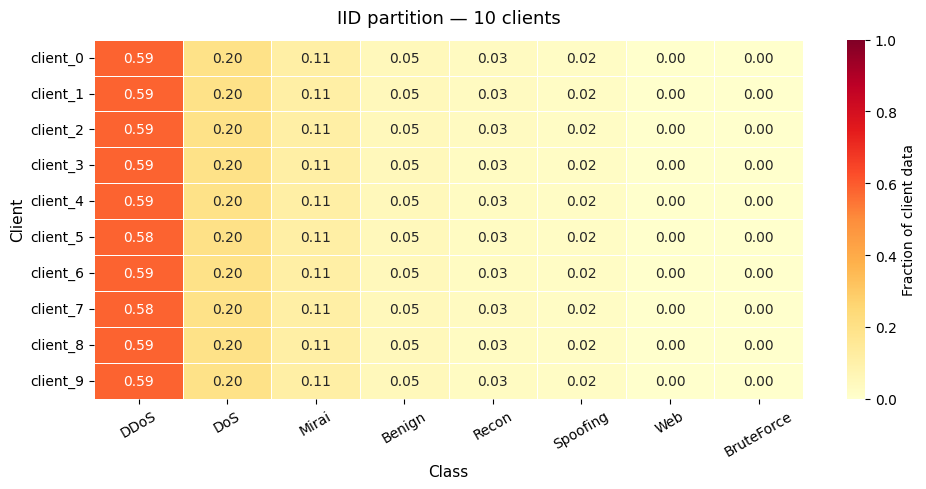

Saved → partition_heatmap_iid.png


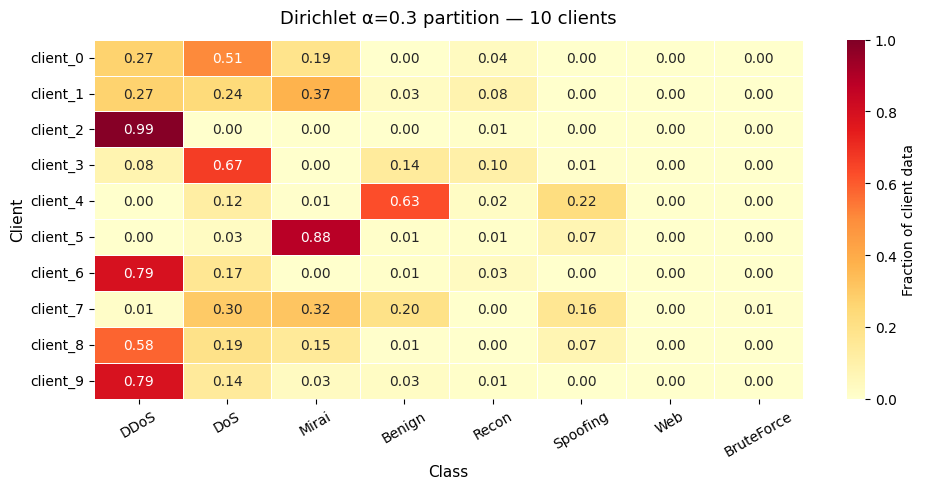

Saved → partition_heatmap_dirichlet_03.png


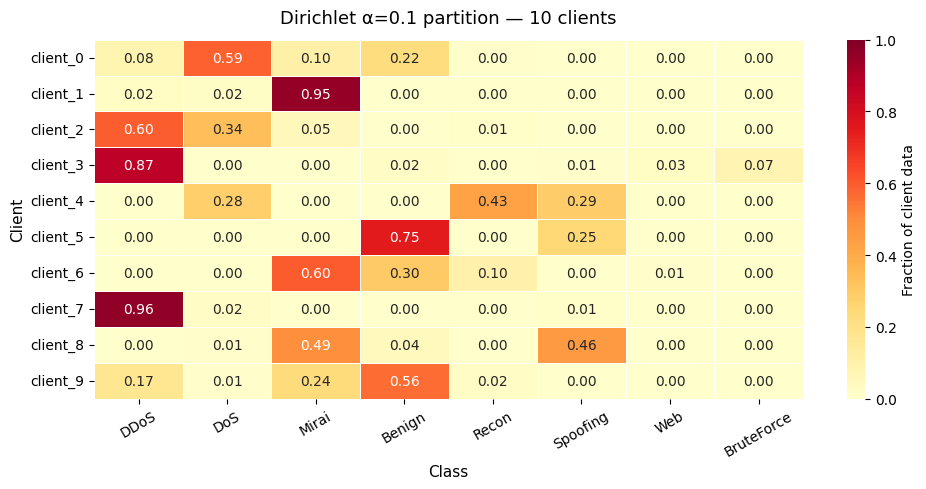

Saved → partition_heatmap_dirichlet_01.png


In [8]:
def plot_partition_heatmap(df_counts, title, save_path):
    # Normalise each row to fractions (client-relative distribution)
    df_frac = df_counts.div(df_counts.sum(axis=1), axis=0)

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(
        df_frac,
        ax=ax,
        annot=True,
        fmt=".2f",
        cmap="YlOrRd",
        linewidths=0.4,
        vmin=0.0,
        vmax=1.0,
        cbar_kws={"label": "Fraction of client data"},
    )
    ax.set_title(title, fontsize=13, pad=12)
    ax.set_xlabel("Class", fontsize=11)
    ax.set_ylabel("Client", fontsize=11)
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {save_path.name}")


plot_partition_heatmap(
    df_iid,
    title=f"IID partition — {NUM_CLIENTS} clients",
    save_path=PLOTS_DIR / "partition_heatmap_iid.png",
)

plot_partition_heatmap(
    df_dir03,
    title=f"Dirichlet α=0.3 partition — {NUM_CLIENTS} clients",
    save_path=PLOTS_DIR / "partition_heatmap_dirichlet_03.png",
)

plot_partition_heatmap(
    df_dir01,
    title=f"Dirichlet α=0.1 partition — {NUM_CLIENTS} clients",
    save_path=PLOTS_DIR / "partition_heatmap_dirichlet_01.png",
)

## Cell 9 — Save partition summary and finish

In [9]:
def client_sizes(splits):
    return [int(len(s)) for s in splits]


summary = {
    "dataset"          : "CICIoT2023",
    "task"             : "cat8_multiclass",
    "total_train"      : int(total_train),
    "num_clients"      : NUM_CLIENTS,
    "num_classes"      : num_classes,
    "class_names"      : class_names,
    "random_seed"      : RANDOM_SEED,
    "schemes": {
        "iid": {
            "client_sizes"     : client_sizes(iid_splits),
            "indices_file"     : "iid_client_indices.npz",
            "class_counts_file": "iid_client_class_counts.csv",
        },
        "dirichlet_03": {
            "alpha"            : 0.3,
            "client_sizes"     : client_sizes(dir03_splits),
            "indices_file"     : "dirichlet_03_client_indices.npz",
            "class_counts_file": "dirichlet_03_client_class_counts.csv",
        },
        "dirichlet_01": {
            "alpha"            : 0.1,
            "client_sizes"     : client_sizes(dir01_splits),
            "indices_file"     : "dirichlet_01_client_indices.npz",
            "class_counts_file": "dirichlet_01_client_class_counts.csv",
        },
    },
}

summary_path = OUTPUT_DIR / "partition_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print(f"partition_summary.json saved → {summary_path}")
print()
print("=" * 60)
print("Partitioning complete. Files written:")
for p in sorted(OUTPUT_DIR.iterdir()):
    print(f"  partitioning/{p.name}")
for p in sorted(PLOTS_DIR.glob("partition_heatmap_*.png")):
    print(f"  plots/{p.name}")
print("=" * 60)
print("Next: run 10_FL_FedAvg.ipynb on the cluster.")

partition_summary.json saved → /Users/satyam/Documents/COS791/CICIoT2023/experiments/stage2_fl/partitioning/partition_summary.json

Partitioning complete. Files written:
  partitioning/.gitkeep
  partitioning/dirichlet_01_client_class_counts.csv
  partitioning/dirichlet_01_client_indices.npz
  partitioning/dirichlet_03_client_class_counts.csv
  partitioning/dirichlet_03_client_indices.npz
  partitioning/iid_client_class_counts.csv
  partitioning/iid_client_indices.npz
  partitioning/partition_summary.json
  plots/partition_heatmap_dirichlet_01.png
  plots/partition_heatmap_dirichlet_03.png
  plots/partition_heatmap_iid.png
Next: run 10_FL_FedAvg.ipynb on the cluster.
